In [10]:
import pandas as pd
import numpy as np
import pyrepseq as prs
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
import seaborn as sns
import os
from scipy import stats
import concurrent.futures
from joblib import Parallel, delayed
import multiprocessing
from scipy import odr
from statannotations.Annotator import Annotator
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [4]:
olga = pd.read_csv('tcrinfo/data/olga.csv',sep=',').astype(str)

In [9]:
cached_backgrounds = {}
cached_backgrounds["Alpha"] = prs.renyi2_entropy(olga, "Alpha")
cached_backgrounds["Beta"] = prs.renyi2_entropy(olga, "Beta")
features = ["CDR3A", "TRAV", "TRAJ"]
for i, feature_1 in enumerate(features):
    for j, feature_2 in enumerate(features[i:], start=i): 
        if feature_1 == feature_2:
            cached_backgrounds[feature_1] = prs.renyi2_entropy(olga, feature_1)
        else:
            cached_backgrounds[(feature_1, feature_2)] = prs.renyi2_entropy(olga, [feature_1, feature_2])
features = ["CDR3B", "TRBV", "TRBJ"]
for i, feature_1 in enumerate(features):
    for j, feature_2 in enumerate(features[i:], start=i): 
        if feature_1 == feature_2:
            cached_backgrounds[feature_1] = prs.renyi2_entropy(olga, feature_1)
        else:
            cached_backgrounds[(feature_1, feature_2)] = prs.renyi2_entropy(olga, [feature_1, feature_2])
np.save("results/twins/cached_backgrouds.npy", cached_backgrounds)

In [5]:
cached_backgrounds = np.load("results/twins/cached_backgrouds.npy", allow_pickle=True).item()

In [7]:
def analysis_significant(twin_result, nontwin_result, features, method='auto', n_permutations=10000, plot=False, alternative='two-sided'):
    """
    Analyze the statistical significance between twin and non-twin results.
    
    Parameters:
    -----------
    twin_result : dict
        Dictionary containing results for twins
    nontwin_result : dict
        Dictionary containing results for non-twins
    features : list or tuple
        Features to analyze. If tuple, contains separate features for rows and columns
    method : str, optional
        Statistical method to use: 'auto' (automatically choose t-test or Mann-Whitney U)
        or 'permutation' (use permutation test)
    n_permutations : int, optional
        Number of permutations for permutation test (only used if method='permutation')
    """
    if isinstance(features, tuple):
        features1 = features[0]
        features2 = features[1]
        upper_triangle_only = False
    else:
        features1 = features
        features2 = features
        upper_triangle_only = True
    pvalues = {}
    
    if plot:
        figsize = (2, 2)
        if upper_triangle_only:
            n_rows = int(len(features1) * (len(features1) + 1) / 2)
            if n_rows %2 !=0: 
                n_cols = 1
                fig, ax = plt.subplots(int(n_rows), n_cols, figsize=(10,10))
            else:
                n_cols = 2
                fig, ax = plt.subplots(int(n_rows/2), n_cols, figsize=(10,10))
        else:
            n_rows = n_cols = len(features1)
            fig, ax = plt.subplots(len(features1), len(features1), figsize=(10,10))
        axes = ax.flatten()
        plot_pointer = 0
    
    for i, feature1 in enumerate(features1):
        for j, feature2 in enumerate(features2):
            if upper_triangle_only and j < i : continue
            
            twins_data = [grid[i,j] for pairs, grid in twin_result.items() if not np.isinf(grid[i,j])]
            nontwins_data = [grid[i,j] for pairs, grid in nontwin_result.items() if not np.isinf(grid[i,j])]
            
            # # Display basic statistics
            # print(f"\nResults for {feature1} and {feature2}:")
            # print(f"Twin mean = {np.mean(twins_data):.4f}, Non-twin mean = {np.mean(nontwins_data):.4f}")
            # print(f"Mean difference = {np.mean(twins_data) - np.mean(nontwins_data):.4f}")
            
            if method == 'auto':
                # Original analysis_significiant logic
                # Check if data follows normal distribution
                stat_twins, p_twins = stats.shapiro(twins_data)
                stat_nontwins, p_nontwins = stats.shapiro(nontwins_data)
                
                # Choose appropriate test based on normality test results
                alpha = 0.05
                if p_twins > alpha and p_nontwins > alpha:
                    # If both groups follow normal distribution, use t-test
                    stat, p_value = stats.ttest_ind(twins_data, nontwins_data)
                    test_name = "Independent t-test"
                else:
                    # If at least one group doesn't follow normal distribution, use Mann-Whitney U test
                    stat, p_value = stats.mannwhitneyu(twins_data, nontwins_data)
                    test_name = "Mann-Whitney U test"

                # print(f"\n{test_name} results:")
                # print(f"Statistic = {stat:.4f}, p-value = {p_value:.4f}")
                
            elif method == 'permutation':
                # Permutation test logic
                # Calculate original difference (using mean difference)
                original_diff = np.mean(twins_data) - np.mean(nontwins_data)
                
                # Combine data for permutation
                combined = twins_data + nontwins_data
                n_twins = len(twins_data)
                
                # Calculate p-value for permutation test
                count_more_extreme = 0
                
                for _ in range(n_permutations):
                    # Randomly shuffle data
                    np.random.shuffle(combined)
                    # Split into two groups
                    perm_twins = combined[:n_twins]
                    perm_nontwins = combined[n_twins:]
                    # Calculate difference after permutation
                    perm_diff = np.mean(perm_twins) - np.mean(perm_nontwins)
                    
                    # Count cases more extreme than original difference (two-tailed test)
                    if alternative == "two-sided":
                        if abs(perm_diff) >= abs(original_diff):
                            count_more_extreme += 1
                    elif alternative == 'greater':
                    # (twins > nontwins) 
                        if perm_diff >= original_diff:
                            count_more_extreme += 1
                    elif alternative == 'less':
                    # (twins < nontwins) 
                        if perm_diff <= original_diff:
                            count_more_extreme += 1
                
                # Calculate p-value for permutation test
                p_value = count_more_extreme / n_permutations
                
                # Output results
                # print(f"\nPermutation test results:")
                # print(f"Original mean difference = {original_diff:.4f}")
                # print(f"Permutation test p-value = {p_value:.4f} (based on {n_permutations} permutations)")
            
            else:
                raise ValueError("Method must be either 'auto' or 'permutation'")
            
            pvalues[(feature1, feature2)] = p_value
            
            if plot:
                df = pd.DataFrame({
                    'Group': ['Twin'] * len(twins_data) + ['Non-twin'] * len(nontwins_data),
                    'I_2(X,Y)': twins_data + nontwins_data
                })
                sns.boxplot(x='Group', y='I_2(X,Y)', ax = axes[plot_pointer], data=df, palette=['#B3242A', '#4048A4'])
                axes[plot_pointer].set_title("X = {}, Y = {}".format(feature1, feature2))
                axes[plot_pointer].xaxis.label.set_visible(False)
                pairs = [("Twin", "Non-twin")]
                annot = Annotator(axes[plot_pointer], pairs, data=df, x='Group', y='I_2(X,Y)')
                # Format p-value text based on significance level
                if p_value < 0.001:
                    p_format = "***"
                elif p_value < 0.01:
                    p_format = "**"
                elif p_value < 0.05:
                    p_format = "*"
                else:
                    p_format = f"NA"
                    
                # Add the annotation
                annot.configure(loc="inside",line_height=0.03,line_width=1)
                annot.set_custom_annotations([p_format])
                annot.annotate()
                plot_pointer += 1
                
    return pvalues

def run_parallel_analysis(dict_grids, n_jobs=-1, celltype="naive"):
    """
    Run permutation tests in parallel using joblib
    
    Parameters:
        dict_grids: Dictionary containing twin/non-twin comparison data
        n_jobs: Number of CPU cores to use (-1 means use all available)
    
    Returns:
        Dictionary containing p-values for all tests
    """
    # Initialize results dictionary
    all_pvalues = {
        'alphabeta': [None] * 100,
        'alpha_part': [None] * 100,
        'beta_part': [None] * 100,
        'cross': [None] * 100
    }
    key_values = list(dict_grids[0].keys())
    
    # Define the function to process a single permutation
    def process_single_permutation(perm_i):
        """Process one permutation and return the results"""
        result = {}
        
        # Test 1: Full alpha-beta chain comparison
        result['alphabeta'] = analysis_significant(
            dict_grids[perm_i][f'twin_alphabeta_grids_{celltype}'], 
            dict_grids[perm_i][f'nontwin_alphabeta_grids_{celltype}'],
            ['Alpha', 'Beta'], plot=False, n_permutations=10000, 
            alternative='greater', method='permutation'
        )
        
        # Test 2: Alpha chain components
        result['alpha_part'] = analysis_significant(
            dict_grids[perm_i][f'twin_alpha_part_grids_{celltype}'], 
            dict_grids[perm_i][f'nontwin_alpha_part_grids_{celltype}'], 
            ["CDR3A", "TRAV", "TRAJ"], method="permutation", 
            plot=False, n_permutations=10000, alternative='greater'
        )
        
        # Test 3: Beta chain components
        result['beta_part'] = analysis_significant(
            dict_grids[perm_i][f'twin_beta_part_grids_{celltype}'], 
            dict_grids[perm_i][f'nontwin_beta_part_grids_{celltype}'], 
            ["CDR3B", "TRBV", "TRBJ"], method="permutation", 
            plot=False, n_permutations=10000, alternative='greater'
        )
        
        # Test 4: Cross-chain interactions
        result['cross'] = analysis_significant(
            dict_grids[perm_i][f'twin_cross_grid_{celltype}'], 
            dict_grids[perm_i][f'nontwin_cross_grid_{celltype}'], 
            (["CDR3A", "TRAV", "TRAJ"], ["CDR3B", "TRBV", "TRBJ"]), 
            method="permutation", plot=False, n_permutations=10000, alternative='greater'
        )
        
        return perm_i, result
    
    # Run the analysis in parallel with a progress bar
    print(f"Starting parallel analysis using {n_jobs} cores...")
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_permutation)(i) for i in range(100)
    )
    
    # Collect results
    for perm_i, result in results:
        all_pvalues['alphabeta'][perm_i] = result['alphabeta']
        all_pvalues['alpha_part'][perm_i] = result['alpha_part']
        all_pvalues['beta_part'][perm_i] = result['beta_part']
        all_pvalues['cross'][perm_i] = result['cross']
        
    return all_pvalues

def create_pvalue_skyline(all_pvalues, savepath, figsize=(16, 8)):
    """
    Create a skyline-style plot showing p-value ranges as buildings
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    x_pos = 0
    x_positions = []
    x_labels = []
    colors = {'alphabeta': '#BD2329', 'alpha_part': '#3498DB', 'beta_part': '#F8A9B7', 'cross': '#7668BA'}
    
    for analysis_type, pval_list in all_pvalues.items():
        if pval_list and pval_list[0]:
            for pair in pval_list[0].keys():
                pvals = [perm_pvals[pair] for perm_pvals in pval_list if perm_pvals]
                pvals = [p for p in pvals if p is not None]
                
                if pvals:
                    p25, p50, p75 = np.percentile(pvals, [25, 50, 75])
                    p5, p95 = np.percentile(pvals, [5, 95])
                    
                    # Draw "building"
                    width = 0.8
                    # Base (5th-95th percentile)
                    ax.bar(x_pos, p95-p5, bottom=p5, width=width, 
                          color=colors[analysis_type], alpha=0.3, edgecolor='black')
                    # IQR (25th-75th percentile)
                    ax.bar(x_pos, p75-p25, bottom=p25, width=width, 
                          color=colors[analysis_type], alpha=0.7, edgecolor='black')
                    # Median line
                    ax.hlines(p50, x_pos-width/2, x_pos+width/2, 
                             colors='grey', linewidth=2)
                    
                    # Label
                    pair_str = f"{pair[0]}-{pair[1]}" if isinstance(pair, tuple) else str(pair)
                    #ax.text(x_pos, -0.05, pair_str, rotation=45, ha='right', va='top')
                    
                    x_positions.append(x_pos)
                    x_pos += 1
                    x_labels.append(pair_str)
                    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', va='top')
    ax.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='p=0.05')
    ax.set_ylim([-0.05, 0.7])
    ax.set_ylabel('P-values')
    ax.set_title('P-value for testing the genetic influence of different regions of TCRs')
    ax.legend()
    if savepath:
        plt.savefig(savepath, transparent=True)
    return fig

def plot_pvalues_distribution(all_pvalues, title="P-value Distribution Across 100 Permutations", figsize=(15, 10)):
    """
    Plot distribution of p-values across multiple permutations and calculate the proportion of significant results
    
    Parameters:
    -----------
    all_pvalues : dict
        Dictionary with keys as analysis types and values as lists of p-value dictionaries
    title : str
        Title for the overall figure
    figsize : tuple
        Figure size (width, height)
    """
    # Count how many feature pairs we have
    feature_pairs = []
    for analysis_type, pval_list in all_pvalues.items():
        if pval_list:  # If the list is not empty
            for pair in pval_list[0].keys():  # Take pairs from first permutation
                feature_pairs.append((analysis_type, pair))
    
    # Create subplots for each feature pair
    n_pairs = len(feature_pairs)
    n_cols = 3  # Adjust based on preference
    n_rows = (n_pairs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    fig.suptitle(title, fontsize=16)
    
    # Flatten axis array for easy indexing
    if n_rows > 1 and n_cols > 1:
        axes = axes.flatten()
    elif n_rows == 1:
        axes = [axes[i] for i in range(n_cols)]
    elif n_cols == 1:
        axes = [axes[i] for i in range(n_rows)]
    
    # For creating a single legend later
    sig_line = None
    p5_line = None
    p95_line = None
    
    # Plot p-values for each feature pair
    for i, (analysis_type, feature_pair) in enumerate(feature_pairs):
        if i < len(axes):
            # Extract p-values for this feature pair across all permutations
            pvals = [perm_pvals[feature_pair] for perm_pvals in all_pvalues[analysis_type]]
            
            # Create the plot
            ax = axes[i]
            ax.hist(pvals, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
            
            # Add reference lines (but don't add to legend here)
            sig_line = ax.axvline(x=0.05, color='red', linestyle='--')
            
            # Calculate percentiles
            p5 = np.percentile(pvals, 5)
            p95 = np.percentile(pvals, 95)
            median = np.median(pvals)
            
            # Add percentile lines
            p5_line = ax.axvline(x=p5, color='green', linestyle=':')
            p95_line = ax.axvline(x=p95, color='blue', linestyle=':')
            
            # Determine consistency of significance
            if p95 < 0.05:
                conclusion = "Consistently significant"
            elif p5 < 0.05 < p95:
                conclusion = "Variably significant"
            else:
                conclusion = "Not significant"
            
            # Set title and labels
            if isinstance(feature_pair, tuple) and len(feature_pair) == 2:
                pair_str = f"{feature_pair[0]}-{feature_pair[1]}"
            else:
                pair_str = str(feature_pair)
                
            ax.set_title(f"{analysis_type}: {pair_str}\n"
                         f"P-value range: {p5:.3f}-{p95:.3f} (median: {median:.3f})\n"
                         f"Conclusion: {conclusion}", fontsize=10)
            ax.set_xlabel('p-value')
            ax.set_ylabel('Frequency')
    
    # Add a single legend in the upper right corner of the figure
    fig.legend(
        [sig_line, p5_line, p95_line],
        ['p=0.05', '5th percentile', '95th percentile'],
        loc='upper right',
        bbox_to_anchor=(1.01, 1.1),
        fontsize=10
    )
    
    # Hide empty subplots
    for i in range(len(feature_pairs), len(axes)):
        axes[i].axis('off')
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, right=0.95)  # Make room for the legend
    
    return fig


NAIVE

Starting parallel analysis using -1 cores...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   25.6s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   32.0s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   38.8s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   48.4s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   58.6s
[Parallel(n_jobs=-1)]: Done  96 out of 100 | elapsed:  1.1min remaining:    2.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.1min finished


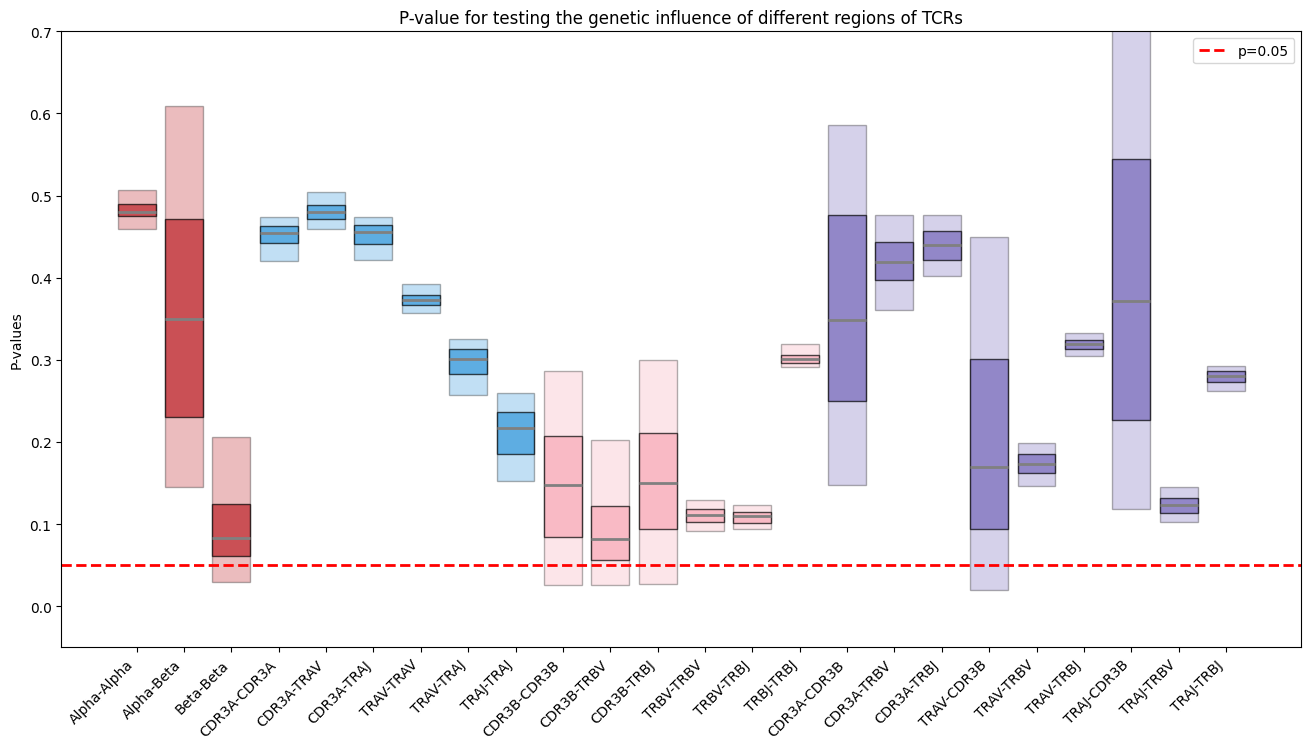

In [9]:
naive_grids = pd.read_pickle("results/twins/naive_grids.pickle")
all_pvalues_naive = run_parallel_analysis(naive_grids, n_jobs=-1, celltype="naive")
fig = create_pvalue_skyline(all_pvalues_naive, savepath = "/mnt/d/TCRMI/figures/twins/p_values_naive.pdf") #"/mnt/d/TCRMI/figures/twins/p_values_naive.pdf"

Memory

Starting parallel analysis using -1 cores...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   23.1s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   29.7s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   36.0s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   44.9s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   54.0s
[Parallel(n_jobs=-1)]: Done  96 out of 100 | elapsed:  1.1min remaining:    2.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.1min finished


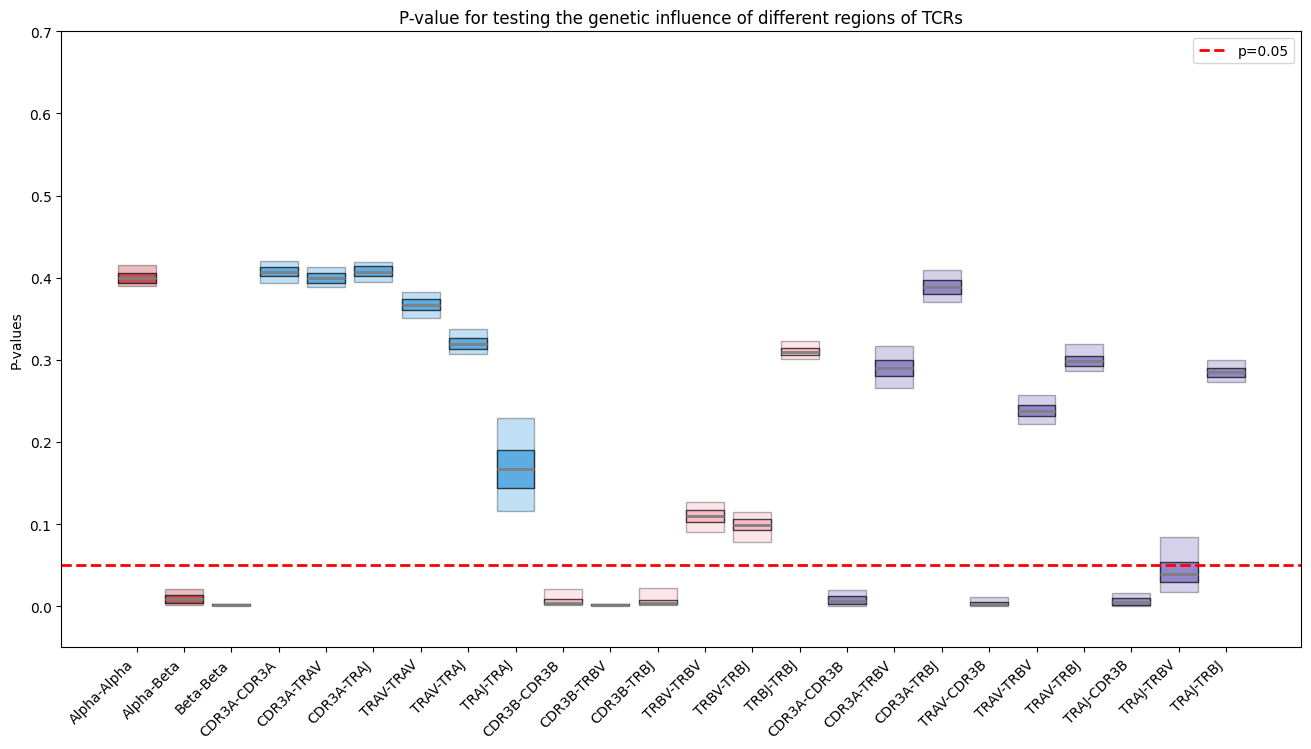

In [12]:
memory_grids = pd.read_pickle("results/twins/memory_grids.pickle")
all_pvalues_memory = run_parallel_analysis(memory_grids, n_jobs=-1, celltype="memory")
fig = create_pvalue_skyline(all_pvalues_memory, savepath = "/mnt/d/TCRMI/figures/twins/p_values_memory.pdf")